<a href="https://colab.research.google.com/github/medijay/msc-ai-phishing-detection/blob/main/notebooks/02_random_forest_model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

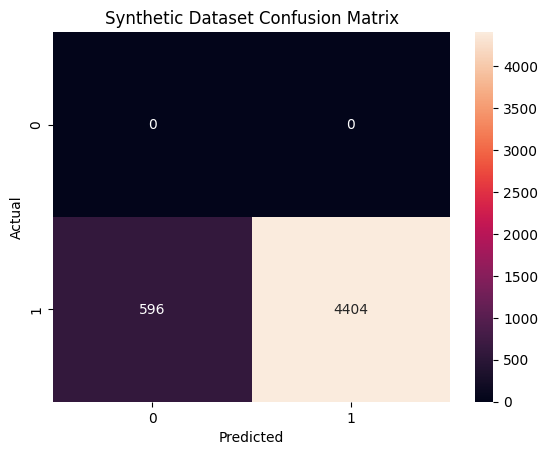

In [39]:
# This notebook implements a baseline phishing detection model
# using Random Forest on the preprocessed Allam dataset.

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/Msc_phishing_Project/datasets/clean_allam_dataset.csv")

df.head()
df.info()
df['label'].value_counts()

X = df['clean_email']
y = df['label']

import re
import nltk

nltk.download('stopwords')

stop_words = set(nltk.corpus.stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r"http\S+", "", text)
    text = re.sub(r"[^a-zA-Z ]", "", text)
    words = text.split()
    words = [word for word in words if word not in stop_words]
    return " ".join(words)

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

X_train.isnull().sum()


df = df.dropna(subset=['clean_email'])

X = df['clean_email']
y = df['label']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec = vectorizer.transform(X_test)

from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train_vec, y_train)

y_pred = rf_model.predict(X_test_vec)

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_test, y_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Random Forest Confusion Matrix")
plt.show()

iwspa_df = pd.read_csv("/content/drive/MyDrive/Msc_phishing_Project/datasets/adversarial_dataset.csv")

iwspa_df.columns

iwspa_df['clean_email'] = iwspa_df['text'].apply(clean_text)

iwspa_df = iwspa_df.dropna(subset=['clean_email'])

X_iwspa = iwspa_df['clean_email']
y_iwspa = iwspa_df['label']

X_iwspa_vec = vectorizer.transform(X_iwspa)

y_iwspa_pred = rf_model.predict(X_iwspa_vec)

from sklearn.metrics import classification_report, accuracy_score

print("Adversarial Dataset Accuracy:", accuracy_score(y_iwspa, y_iwspa_pred))
print(classification_report(y_iwspa, y_iwspa_pred))

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_iwspa, y_iwspa_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Adversarial Dataset Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

synthetic_df = pd.read_csv("/content/drive/MyDrive/Msc_phishing_Project/datasets/synthetic_phish.csv")

synthetic_df.head()
synthetic_df.columns
synthetic_df.info()

synthetic_df.columns

synthetic_df['clean_email'] = synthetic_df['text'].apply(clean_text)

synthetic_df = synthetic_df.dropna(subset=['clean_email'])

X_syn = synthetic_df['clean_email']
y_syn = synthetic_df['label']

X_syn_vec = vectorizer.transform(X_syn)

y_syn_pred = rf_model.predict(X_syn_vec)

from sklearn.metrics import classification_report, accuracy_score

print("Synthetic Dataset Accuracy:", accuracy_score(y_syn, y_syn_pred))
print(classification_report(y_syn, y_syn_pred))

from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_syn, y_syn_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Synthetic Dataset Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()